# Import các thư viện

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Data Mining

### Bước 1: Đọc dữ liệu từ file CSV đã tiền xử lý

In [18]:
df = pd.read_csv('car_sales_data_cleaned.csv')

df.head(5)

,brand,model,engine_size,fuel_type,year,mileage_km,price_usd,age,price_per_1k_km,mileage_bucket_label,mileage_bucket_order,age_bucket_label,age_bucket_order,overprice_threshold,is_overpriced
0,Ford,Fiesta,1.0,Petrol,2002,127300,3074,23,24.147683,>100k,4,10y+,4,24653.000,False
1,Porsche,718 Cayman,4.0,Petrol,2016,57850,49704,9,859.187554,50-100k,3,6-10y,3,73239.750,False
2,Ford,Mondeo,1.6,Diesel,2014,39190,24072,11,614.238326,20-50k,2,10y+,4,43916.000,False
3,Toyota,RAV4,1.8,Hybrid,1988,210814,1705,37,8.087698,>100k,4,10y+,4,66286.875,False
4,VW,Polo,1.0,Petrol,2006,127869,4101,19,32.071886,>100k,4,10y+,4,26969.875,False


In [19]:
print("Tổng số bản ghi:", len(df))

Tổng số bản ghi: 50000


In [20]:
print("Các cột trong dataset:")
print(df.columns)

Các cột trong dataset:
Index(['brand', 'model', 'engine_size', 'fuel_type', 'year', 'mileage_km',
       'price_usd', 'age', 'price_per_1k_km', 'mileage_bucket_label',
       'mileage_bucket_order', 'age_bucket_label', 'age_bucket_order',
       'overprice_threshold', 'is_overpriced'],
      dtype='object')


### Bước 2: Lựa chọn các thuộc tính đầu vào và đầu ra cho mô hình

- Chọn các feature để huấn luyện mô hình.

In [21]:
features = ['model', 'fuel_type', 'engine_size', 'age', 'mileage_km']
target = 'price_usd'

data = df[features + [target]].copy()
print("Các cột dùng cho mô hình:", data.columns)

Các cột dùng cho mô hình: Index(['model', 'fuel_type', 'engine_size', 'age', 'mileage_km', 'price_usd'], dtype='object')


- Chia tập train, test.

In [22]:
X = data[features]
y = data[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train size:", X_train.shape[0], "records;", "Test size:", X_test.shape[0], "records")

Train size: 40000 records; Test size: 10000 records


### Bước 3: Tiền xử lý dữ liệu - mã hóa biến phân loại và chuẩn hóa biến số

3.1. Mã hóa one-hot cho các biến phân loại (model, fuel_type)

In [23]:
# Sử dụng OneHotEncoder của scikit-learn với drop='first' để tránh dummy trap
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

X_train_cat = ohe.fit_transform(X_train[['model', 'fuel_type']])
X_test_cat = ohe.transform(X_test[['model', 'fuel_type']])

In [24]:
# Lấy danh sách tên các feature sau khi one-hot
cat_feature_names = ohe.get_feature_names_out(['model', 'fuel_type'])
print("Số lượng features sau one-hot:", len(cat_feature_names))

Số lượng features sau one-hot: 16


3.2. Chuẩn hóa các biến số (engine_size, age, mileage_km)

In [25]:
scaler = StandardScaler()

X_train_num = scaler.fit_transform(X_train[['engine_size', 'age', 'mileage_km']])
X_test_num = scaler.transform(X_test[['engine_size', 'age', 'mileage_km']])

3.3. Kết hợp dữ liệu số và dữ liệu mã hóa thành ma trận đặc trưng cuối cùng

In [26]:
X_train_prepared = np.hstack([X_train_num, X_train_cat])
X_test_prepared = np.hstack([X_test_num, X_test_cat])

num_feature_names = ['engine_size', 'age', 'mileage_km']
feature_names = num_feature_names + list(cat_feature_names)

print("Kích thước ma trận X_train_prepared:", X_train_prepared.shape)
print("Kích thước ma trận X_test_prepared:", X_test_prepared.shape)

Kích thước ma trận X_train_prepared: (40000, 19)
Kích thước ma trận X_test_prepared: (10000, 19)


### Bước 4: Huấn luyện mô hình & đánh giá

4.1. Huấn luyện mô hình Linear Regression

In [27]:
model_lr = LinearRegression()

model_lr.fit(X_train_prepared, y_train)
y_pred_lr = model_lr.predict(X_test_prepared)

In [28]:
# Tính các chỉ số đánh giá cho Linear Regression
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression - RMSE: {:.2f}, MAE: {:.2f}, R^2: {:.3f}".format(rmse_lr, mae_lr, r2_lr))

Linear Regression - RMSE: 8868.26, MAE: 5786.31, R^2: 0.710


4.2. Huấn luyện mô hình Decision Tree

In [29]:
model_dt = DecisionTreeRegressor(random_state=42)
model_dt.fit(X_train_prepared, y_train)
y_pred_dt = model_dt.predict(X_test_prepared)

In [30]:
# Tính các chỉ số đánh giá cho Decision Tree
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree - RMSE: {:.2f}, MAE: {:.2f}, R^2: {:.3f}".format(rmse_dt, mae_dt, r2_dt))

Decision Tree - RMSE: 1064.29, MAE: 464.66, R^2: 0.996


4.3. Huấn luyện mô hình Random Forest

In [31]:
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train_prepared, y_train)
y_pred_rf = model_rf.predict(X_test_prepared)

In [32]:
# Tính các chỉ số đánh giá cho Random Forest
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest - RMSE: {:.2f}, MAE: {:.2f}, R^2: {:.3f}".format(rmse_rf, mae_rf, r2_rf))

Random Forest - RMSE: 676.93, MAE: 311.14, R^2: 0.998


4.4. Huấn luyện mô hình XGBoost

In [33]:
model_xgb = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
model_xgb.fit(X_train_prepared, y_train)
y_pred_xgb = model_xgb.predict(X_test_prepared)

In [34]:
# Tính các chỉ số đánh giá cho XGBoost
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost - RMSE: {:.2f}, MAE: {:.2f}, R^2: {:.3f}".format(rmse_xgb, mae_xgb, r2_xgb))

XGBoost - RMSE: 598.93, MAE: 349.95, R^2: 0.999


4.5. Đánh giá các mô hình

In [35]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'XGBoost'],
    'RMSE': [rmse_lr, rmse_dt, rmse_rf, rmse_xgb],
    'MAE': [mae_lr, mae_dt, mae_rf, mae_xgb],
    'R2':  [r2_lr, r2_dt, r2_rf, r2_xgb]
})
results = results.set_index('Model')
print("Hiệu năng của các mô hình trên tập test:")
display(results)

Hiệu năng của các mô hình trên tập test:


,RMSE,MAE,R2
Model,,,
Linear Regression,8868.260690,5786.313143,0.710194
Decision Tree,1064.288638,464.661100,0.995826
Random Forest,676.930989,311.139586,0.998311
XGBoost,598.929227,349.945190,0.998678


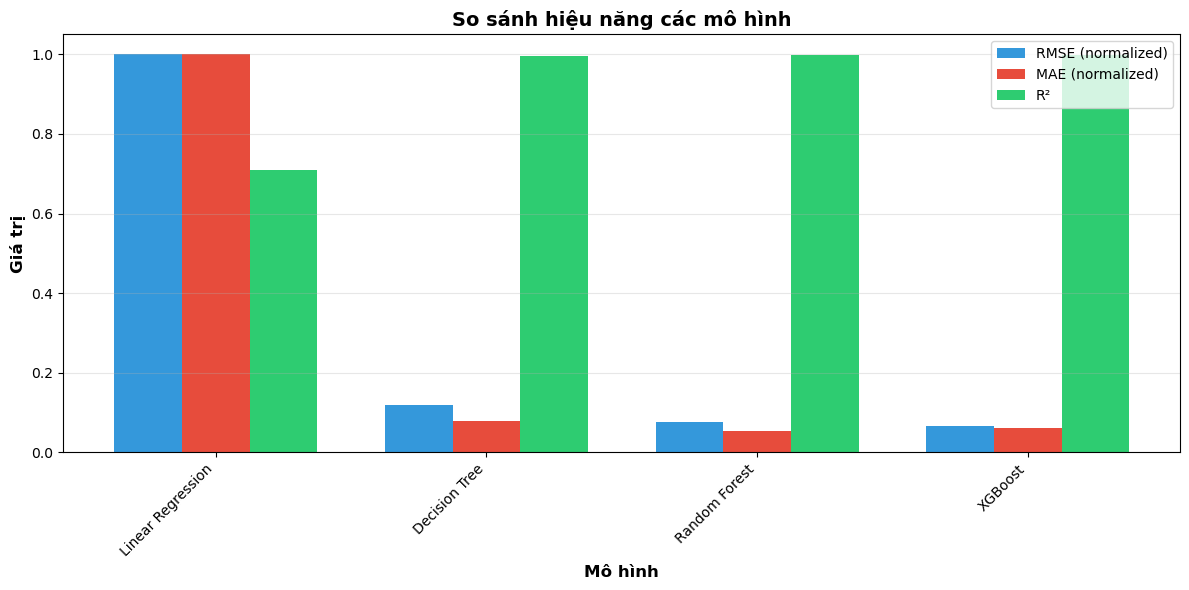

In [36]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(results.index))
width = 0.25

rmse_normalized = results['RMSE'] / results['RMSE'].max()
mae_normalized = results['MAE'] / results['MAE'].max()

bars1 = ax.bar(x - width, rmse_normalized, width, label='RMSE (normalized)', color='#3498db')
bars2 = ax.bar(x, mae_normalized, width, label='MAE (normalized)', color='#e74c3c')
bars3 = ax.bar(x + width, results['R2'], width, label='R²', color='#2ecc71')

ax.set_xlabel('Mô hình', fontsize=12, fontweight='bold')
ax.set_ylabel('Giá trị', fontsize=12, fontweight='bold')
ax.set_title('So sánh hiệu năng các mô hình', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results.index, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Bước 5: K-Fold Cross Validation để đánh giá khả năng tổng quát hóa

- Thiết lập số fold cho K-Fold Cross Validation

In [37]:
k = 10
kfold = KFold(n_splits=k, shuffle=True, random_state=42)

- Gom các mô hình lại thành dict để lặp

In [38]:
models_cv = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
}

cv_rows = []

for name, model in models_cv.items():
    neg_rmse_scores = cross_val_score(
        model,
        X_train_prepared,
        y_train,
        scoring="neg_root_mean_squared_error",
        cv=kfold
    )
    
    r2_scores = cross_val_score(
        model,
        X_train_prepared,
        y_train,
        scoring="r2",
        cv=kfold
    )
    
    cv_rows.append({
        "Model": name,
        "CV_RMSE_Mean": -neg_rmse_scores.mean(),
        "CV_RMSE_Std":  neg_rmse_scores.std(),
        "CV_R2_Mean":   r2_scores.mean(),
        "CV_R2_Std":    r2_scores.std()
    })

cv_results = pd.DataFrame(cv_rows).set_index("Model")

print(f"Kết quả K-Fold Cross Validation (k = {k}):")
display(cv_results)

Kết quả K-Fold Cross Validation (k = 10):


,CV_RMSE_Mean,CV_RMSE_Std,CV_R2_Mean,CV_R2_Std
Model,,,,
Linear Regression,8737.370744,409.378542,0.715988,0.010069
Decision Tree,1094.362406,34.395829,0.995526,0.000388
Random Forest,734.426788,40.925668,0.997987,0.000200
XGBoost,645.863037,18.960734,0.998440,0.000150


### Bước 6: Trực quan hóa mô hình tốt nhất (XGBoost)

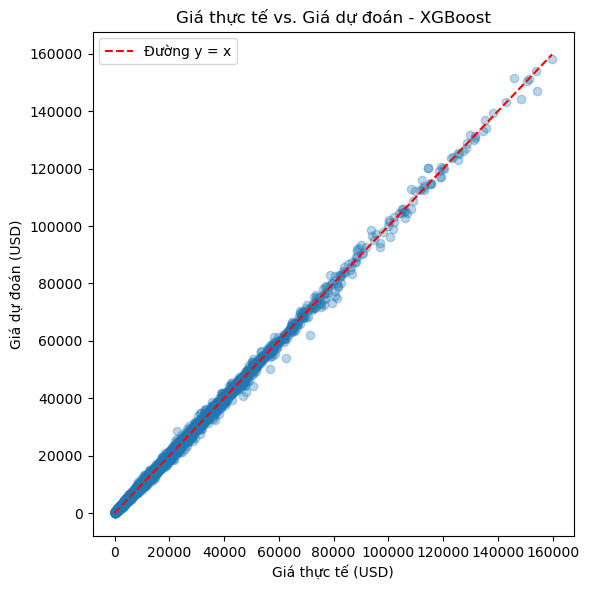

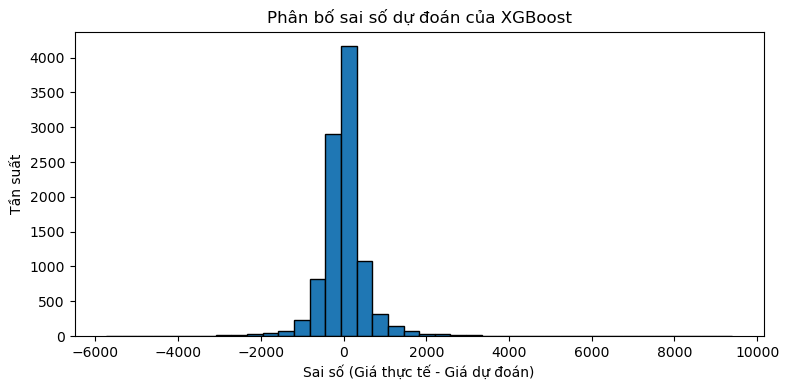

In [39]:
best_model = model_xgb
y_pred_best = y_pred_xgb

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_best, alpha=0.3)
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--", label="Đường y = x")
plt.xlabel("Giá thực tế (USD)")
plt.ylabel("Giá dự đoán (USD)")
plt.title("Giá thực tế vs. Giá dự đoán - XGBoost")
plt.legend()
plt.tight_layout()
plt.show()

residuals = y_test - y_pred_best
plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=40, edgecolor="k")
plt.xlabel("Sai số (Giá thực tế - Giá dự đoán)")
plt.ylabel("Tần suất")
plt.title("Phân bố sai số dự đoán của XGBoost")
plt.tight_layout()
plt.show()

### Bước 7: Phân tích tầm quan trọng của thuộc tính (Feature Importance)

- Tầm quan trọng thuộc tính đối với Random Forest

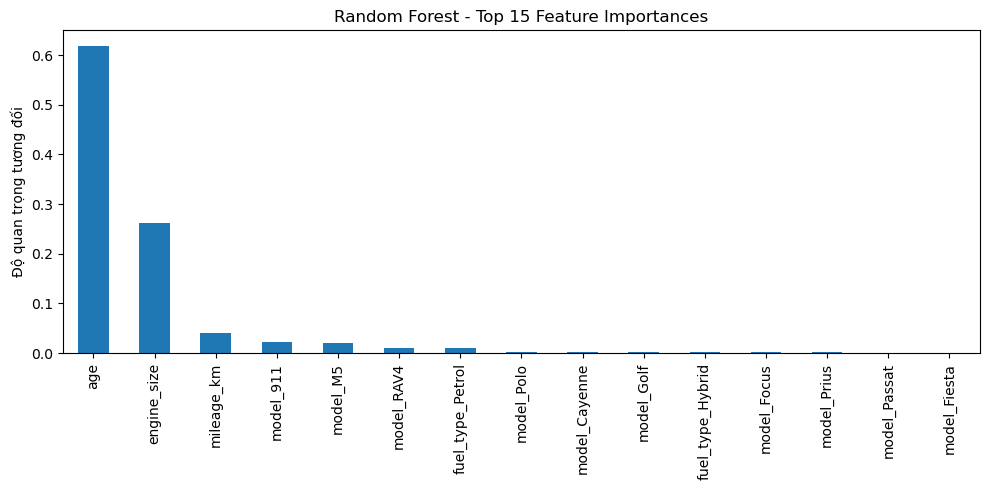

age                 0.618744
engine_size         0.262710
mileage_km          0.040125
model_911           0.021771
model_M5            0.020957
model_RAV4          0.010030
fuel_type_Petrol    0.009487
model_Polo          0.003046
model_Cayenne       0.002698
model_Golf          0.002601
fuel_type_Hybrid    0.001885
model_Focus         0.001546
model_Prius         0.001360
model_Passat        0.000918
model_Fiesta        0.000652
dtype: float64

In [40]:
rf_importances = model_rf.feature_importances_
fi_rf = pd.Series(rf_importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
fi_rf.head(15).plot(kind="bar")
plt.title("Random Forest - Top 15 Feature Importances")
plt.ylabel("Độ quan trọng tương đối")
plt.tight_layout()
plt.show()

display(fi_rf.head(15))


- Tầm quan trọng thuộc tính đối với XGBoost

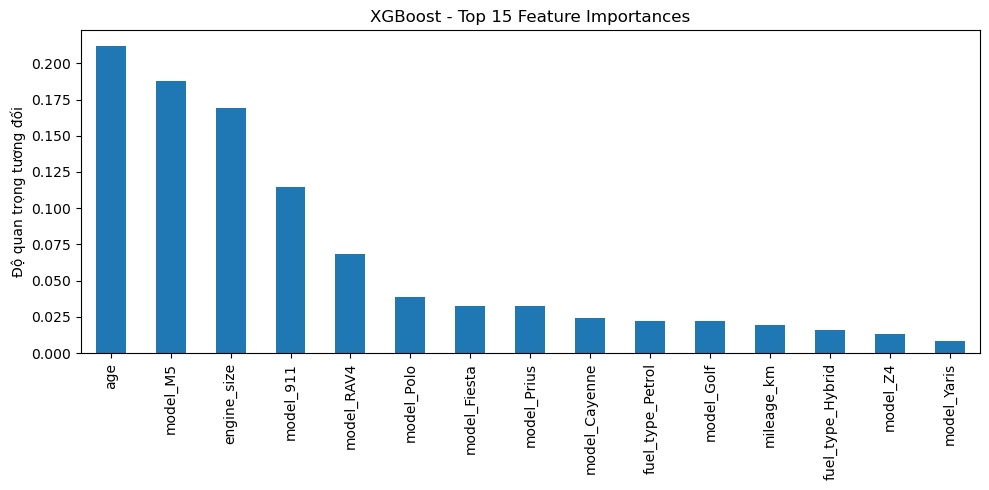

age                 0.212169
model_M5            0.187931
engine_size         0.169483
model_911           0.114758
model_RAV4          0.068304
model_Polo          0.038497
model_Fiesta        0.032394
model_Prius         0.032292
model_Cayenne       0.024041
fuel_type_Petrol    0.021997
model_Golf          0.021936
mileage_km          0.019441
fuel_type_Hybrid    0.015768
model_Z4            0.013037
model_Yaris         0.008106
dtype: float32

In [41]:
xgb_importances = model_xgb.feature_importances_
fi_xgb = pd.Series(xgb_importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
fi_xgb.head(15).plot(kind="bar")
plt.title("XGBoost - Top 15 Feature Importances")
plt.ylabel("Độ quan trọng tương đối")
plt.tight_layout()
plt.show()

display(fi_xgb.head(15))